# Stepwise Molecular Assembly Simulation

**Goal:** Simulate 6 different molecules diffusing on a 2D surface and assembling in a stepwise manner. Each molecule is labeled with a unique dye, and we visualize the assembly process using ground truth RGB rendering.

**Assembly Process:**
- Molecules A, B, C, D, E, F labeled with 6 different spectral dyes
- Stepwise assembly: A+B → AB, AB+C → ABC, ABC+D → ABCD, etc.
- Visualize as colors combine to form multi-color complexes

**Output:**
- Ground truth RGB video showing assembly dynamics
- Color combinations reveal binding states

In [1]:
import sys
sys.path.insert(0, '../../src')

import numpy as np
import matplotlib.pyplot as plt
from DiffusionSimulation import (
    DiffusionSimulator2D,
    CameraAdapter
)

# Set random seed for reproducibility
np.random.seed(42)

print("Imports successful!")

Imports successful!


## 1. Define Binding Kinetics Matrix

We'll create a binding matrix for stepwise assembly:
- A + B ⇌ AB (fast)
- AB + C ⇌ ABC (moderate)
- ABC + D ⇌ ABCD (moderate)
- ABCD + E ⇌ ABCDE (slow)
- ABCDE + F ⇌ ABCDEF (slow)

This creates a hierarchical assembly pathway.

In [2]:
# Define 6 molecule types (colors)
# We'll use spectral colors spanning the visible spectrum
molecules = {
    'A': {'color': 'Blue',   'A_R': 0.05, 'A_G': 0.15, 'A_B': 0.80},  # Deep blue
    'B': {'color': 'Cyan',   'A_R': 0.10, 'A_G': 0.50, 'A_B': 0.40},  # Cyan
    'C': {'color': 'Green',  'A_R': 0.15, 'A_G': 0.75, 'A_B': 0.10},  # Green
    'D': {'color': 'Yellow', 'A_R': 0.50, 'A_G': 0.45, 'A_B': 0.05},  # Yellow
    'E': {'color': 'Orange', 'A_R': 0.70, 'A_G': 0.25, 'A_B': 0.05},  # Orange
    'F': {'color': 'Red',    'A_R': 0.80, 'A_G': 0.15, 'A_B': 0.05},  # Red
}

# Create color list for binding matrix
colors = ['Blue', 'Cyan', 'Green', 'Yellow', 'Orange', 'Red']
n_species = len(colors)

print("Molecule spectral profiles:")
for name, props in molecules.items():
    print(f"  {name} ({props['color']:6s}): R={props['A_R']:.2f}, G={props['A_G']:.2f}, B={props['A_B']:.2f}")

Molecule spectral profiles:
  A (Blue  ): R=0.05, G=0.15, B=0.80
  B (Cyan  ): R=0.10, G=0.50, B=0.40
  C (Green ): R=0.15, G=0.75, B=0.10
  D (Yellow): R=0.50, G=0.45, B=0.05
  E (Orange): R=0.70, G=0.25, B=0.05
  F (Red   ): R=0.80, G=0.15, B=0.05


In [ ]:
k_on  = np.zeros((n_species, n_species))
k_off = np.zeros((n_species, n_species))

binding_radius = 500  # nm

# Step 1: A + B → AB  (fast on, very stable)
k_on[0, 1] = k_on[1, 0] = 20.0
k_off[0, 1] = k_off[1, 0] = 0.05   # τ = 20 s

# Step 2: AB + C → ABC  (fast on, stable)
k_on[1, 2] = k_on[2, 1] = 15.0
k_off[1, 2] = k_off[2, 1] = 0.08   # τ = 12.5 s

# Step 3: ABC + D → ABCD  (moderate on, now stable)
k_on[2, 3] = k_on[3, 2] = 10.0
k_off[2, 3] = k_off[3, 2] = 0.05   # τ = 20 s  (was 0.15 → 6.7 s)

# Step 4: ABCD + E → ABCDE  (was the bottleneck — faster on, now stable)
k_on[3, 4] = k_on[4, 3] = 10.0     # was 5  → τ_wait halved to ~1.6 s
k_off[3, 4] = k_off[4, 3] = 0.05   # was 0.20 → τ: 5 s → 20 s

# Step 5: ABCDE + F → ABCDEF  (slow on, very stable final latch)
k_on[4, 5] = k_on[5, 4] = 5.0
k_off[4, 5] = k_off[5, 4] = 0.03   # τ = 33 s

# ── summary ──────────────────────────────────────────────────────────────
steps = [
    ('A–B',    0, 1),
    ('B–C',    1, 2),
    ('C–D',    2, 3),
    ('D–E',    3, 4),
    ('E–F',    4, 5),
]

c = 100 / 1600   # expected molecules/µm² per species at 600 total in 1600 µm²

print(f"{'Step':<6} {'k_on':>8} {'k_off':>8} {'τ_bound':>9} {'K_d':>9} {'rate_on':>9} {'τ_wait':>8} {'f_eq':>7}")
print("-" * 70)
for label, i, j in steps:
    kon  = k_on[i, j]
    koff = k_off[i, j]
    tau_b   = 1 / koff
    kd      = koff / kon
    rate_on = kon * c
    tau_w   = 1 / rate_on
    feq     = c / (kd + c)
    print(f"{label:<6} {kon:>8.1f} {koff:>8.3f} {tau_b:>8.1f}s {kd:>8.4f} {rate_on:>8.3f}/s {tau_w:>7.1f}s {feq:>7.1%}")

f_total = np.prod([c / (k_off[i,j]/k_on[i,j] + c) for _, i, j in steps])
print(f"\nP(ABCDEF) at equilibrium (upper bound, no depletion): {f_total:.1%}")
print(f"Binding radius: {binding_radius} nm")

## 2. Initialize Diffusion Simulator with Binding Kinetics

Create a 2D simulation area with realistic parameters:
- 40 µm × 40 µm area (typical widefield FOV)
- 20 ms frame time
- Reflective boundaries (molecules stay in field of view)
- Binding kinetics for stepwise assembly

In [ ]:
# Import BindingKinetics class
from DiffusionSimulation import BindingKinetics

# Simulation parameters
area = (53333, 30000)  # 53.3 × 30 µm in nm  (16:9 widefield FOV, same 1600 µm² area)
dt = 20.0              # 20 ms frame time
t_exposure = 20.0      # 20 ms exposure
sigma0 = 20.0          # 20 nm base localization error
s0 = 150.0             # 150 nm PSF width

# Create binding kinetics object
binding_kinetics = BindingKinetics(
    colors=colors,
    k_on_matrix=k_on,
    k_off_matrix=k_off,
    binding_radius=binding_radius
)

# Initialize simulator with binding kinetics
simulator = DiffusionSimulator2D(
    area=area,
    dt=dt,
    t_exposure=t_exposure,
    sigma0=sigma0,
    s0=s0,
    boundary='reflective',
    binding_kinetics=binding_kinetics
)

area_um2 = (area[0] / 1000) * (area[1] / 1000)
print(f"Simulator initialized:")
print(f"  Area: {area[0]/1000:.1f} × {area[1]/1000:.0f} µm  ({area_um2:.0f} µm²)  [16:9]")
print(f"  Frame time: {dt} ms")
print(f"  Localization error: {sigma0} nm")
print(f"  Binding enabled: ✓")

## 3. Add Molecules to Simulation

Add several copies of each molecule type, distributed throughout the field of view.

**Diffusion coefficients:**
- Free molecules: ~1 µm²/s (typical for small proteins)
- Bound complexes: ~0.2 µm²/s (slower due to larger size)

In [ ]:
# 600 molecules total → 100 per species
n_total      = 600
n_per_species = n_total // n_species   # 100

# Diffusion coefficients (µm²/s)
D_free  = 10   # Free diffusion
D_bound = 5    # Bound complex diffusion (2× slower)

dt_s      = dt / 1000
rms_free  = np.sqrt(4 * D_free  * 1e6 * dt_s)
rms_bound = np.sqrt(4 * D_bound * 1e6 * dt_s)

effective_density = n_total / area_um2
print(f"Molecules:   {n_total} total  ({n_per_species} per species)")
print(f"Density:     {effective_density:.3f} mol/µm²  "
      f"(1 per {1/effective_density:.1f} µm²)")
print(f"Diffusion:")
print(f"  D_free:  {D_free} µm²/s  (RMS {rms_free:.0f} nm/frame)")
print(f"  D_bound: {D_bound} µm²/s  (RMS {rms_bound:.0f} nm/frame)")

molecule_ids = {color: [] for color in colors}

for name, props in molecules.items():
    color = props['color']
    for j in range(n_per_species):
        x0 = np.random.uniform(0.05 * area[0], 0.95 * area[0])
        y0 = np.random.uniform(0.05 * area[1], 0.95 * area[1])
        mol = simulator.add_molecule(
            color=color,
            position=np.array([x0, y0]),
            D_free=D_free,
            D_bound=D_bound,
            spectral_profile={'A_R': props['A_R'], 'A_G': props['A_G'], 'A_B': props['A_B']}
        )
        molecule_ids[color].append(mol.molecule_id)

print(f"\nAdded {len(simulator.molecules)} molecules:")
for color in colors:
    print(f"  {color:6s}: {len(molecule_ids[color])}")

## 4. Run Simulation

Simulate for several seconds to observe assembly dynamics.

**Timeline:**
- 0-5s: Initial diffusion and first binding events (A+B)
- 5-10s: Secondary assembly (AB+C, ABC+D)
- 10-20s: Higher-order complexes (ABCD+E, ABCDE+F)
- 20-30s: Steady state with fully assembled complexes

In [6]:
# Simulation duration
duration = 60.0  # seconds
n_frames = int(duration * 1000 / dt)  # Convert to number of frames

print(f"Running simulation...")
print(f"  Duration: {duration} s")
print(f"  Frames: {n_frames} ({dt} ms each)")
print(f"  Total time: {n_frames * dt / 1000:.1f} s")
print()

# Run simulation with binding enabled
simulator.run(
    n_steps=n_frames,
    enable_binding=True
)

# Get binding events
n_bind = len(simulator.binding_kinetics.binding_events)
n_unbind = len(simulator.binding_kinetics.unbinding_events)

print(f"\n✅ Simulation complete!")
print(f"  Trajectories generated for {len(simulator.molecules)} molecules")
print(f"  Binding events: {n_bind}")
print(f"  Unbinding events: {n_unbind}")
print(f"  Total events: {n_bind + n_unbind}")

Running simulation...
  Duration: 60.0 s
  Frames: 3000 (20.0 ms each)
  Total time: 60.0 s


✅ Simulation complete!
  Trajectories generated for 30 molecules
  Binding events: 9
  Unbinding events: 0
  Total events: 9


In [ ]:
# ============================================================
# Save molecule trajectories + simulation metadata to HDF5
#
# This preserves the full simulation state so that the Bayer
# image simulation (and any downstream analysis) can be
# restarted from here without re-running the diffusion engine.
#
# Dataset layout
# --------------
# /metadata          — scalar attrs (area, dt, n_frames, …)
# /trajectories/<Color>  — (n_mols, n_frames, 2) float32, nm
# /binding_events/   — parallel 1-D arrays (time, ids, colors)
# /unbinding_events/ — same structure
# ============================================================
import h5py

output_path_h5 = 'stepwise_assembly_trajectories.h5'

with h5py.File(output_path_h5, 'w') as f:

    # --- metadata ---
    meta = f.create_group('metadata')
    meta.attrs['n_frames']        = n_frames
    meta.attrs['dt_ms']           = dt
    meta.attrs['duration_s']      = duration
    meta.attrs['area_nm']         = np.array(area, dtype=np.float64)
    meta.attrs['n_species']       = n_species
    meta.attrs['n_per_species']   = n_per_species
    meta.attrs['D_free_um2s']     = D_free
    meta.attrs['D_bound_um2s']    = D_bound
    meta.attrs['binding_radius_nm'] = binding_radius
    meta.attrs['colors']          = colors          # list of strings

    # --- trajectories ---
    # Shape: (n_mols, n_frames, 2)  units: nm
    # axis 0 = molecule index within colour group
    # axis 1 = frame
    # axis 2 = [x, y]
    traj_grp = f.create_group('trajectories')
    for color in colors:
        mols_c = [m for m in simulator.molecules if m.color == color]
        if not mols_c:
            continue
        arr = np.stack(
            [np.asarray(m.trajectory, dtype=np.float32) for m in mols_c],
            axis=0,
        )   # (n_mols, n_frames, 2)
        ds = traj_grp.create_dataset(
            color, data=arr, compression='gzip', compression_opts=4,
        )
        ds.attrs['n_molecules'] = len(mols_c)
        ds.attrs['units']       = 'nm'
        ds.attrs['axes']        = 'molecule, frame, [x y]'

    # --- binding events ---
    _str_dt = h5py.string_dtype()
    for grp_name, events in [('binding_events',   binding_events),
                              ('unbinding_events', unbinding_events)]:
        if not events:
            continue
        eg = f.create_group(grp_name)
        eg.create_dataset('time_ms',
            data=np.array([e['time']       for e in events], dtype=np.float64))
        eg.create_dataset('mol1_id',
            data=np.array([e['mol1_id']    for e in events], dtype=np.int64))
        eg.create_dataset('mol2_id',
            data=np.array([e['mol2_id']    for e in events], dtype=np.int64))
        eg.create_dataset('mol1_color',
            data=np.array([e['mol1_color'] for e in events], dtype=object),
            dtype=_str_dt)
        eg.create_dataset('mol2_color',
            data=np.array([e['mol2_color'] for e in events], dtype=object),
            dtype=_str_dt)

print(f"✅ Trajectories saved: {output_path_h5}")
print(f"   Frames: {n_frames}  |  Species: {n_species}  |  Mols/species: {n_per_species}")
print(f"   Binding events:   {len(binding_events)}")
print(f"   Unbinding events: {len(unbinding_events)}")
for color in colors:
    mols_c = [m for m in simulator.molecules if m.color == color]
    n_m    = len(mols_c)
    sz_mb  = n_m * n_frames * 2 * 4 / 1e6   # float32
    print(f"   {color:6s}: {n_m} mols  ({sz_mb:.1f} MB uncompressed)")

## 5. Analyze Binding Events

Examine the binding history to see assembly progression.

In [7]:
# Analyze binding events
binding_events = simulator.binding_kinetics.binding_events
unbinding_events = simulator.binding_kinetics.unbinding_events
all_events = binding_events + unbinding_events

if len(all_events) > 0:
    print(f"Binding Events Summary:")
    print(f"  Binding events: {len(binding_events)}")
    print(f"  Unbinding events: {len(unbinding_events)}")
    print(f"  Total events: {len(all_events)}")
    print()
    
    # Show first 10 events
    print(f"First 10 events:")
    
    # Combine and sort all events by time
    combined_events = []
    for event in binding_events:
        combined_events.append({
            'type': 'bind',
            'time': event['time'],
            'mol1_id': event['mol1_id'],
            'mol2_id': event['mol2_id'],
            'mol1_color': event['mol1_color'],
            'mol2_color': event['mol2_color']
        })
    
    for event in unbinding_events:
        combined_events.append({
            'type': 'unbind',
            'time': event['time'],
            'mol1_id': event['mol1_id'],
            'mol2_id': event['mol2_id'],
            'mol1_color': event['mol1_color'],
            'mol2_color': event['mol2_color']
        })
    
    # Sort by time
    combined_events.sort(key=lambda x: x['time'])
    
    for i, event in enumerate(combined_events[:10]):
        time_s = event['time'] / 1000  # Convert ms to s
        
        if event['type'] == 'bind':
            print(f"  [{time_s:6.2f}s] {event['mol1_color']:6s} + {event['mol2_color']:6s} → BOUND")
        else:
            print(f"  [{time_s:6.2f}s] {event['mol1_color']:6s} - {event['mol2_color']:6s} → UNBOUND")
    
    if len(combined_events) > 10:
        print(f"  ... ({len(combined_events) - 10} more events)")
else:
    print("⚠️  No binding events occurred (try longer simulation or higher k_on)")

Binding Events Summary:
  Binding events: 9
  Unbinding events: 0
  Total events: 9

First 10 events:
  [  0.16s] Blue   + Cyan   → BOUND
  [  0.56s] Green  + Yellow → BOUND
  [  0.87s] Yellow + Orange → BOUND
  [  1.15s] Blue   + Cyan   → BOUND
  [  1.92s] Cyan   + Green  → BOUND
  [  5.62s] Cyan   + Green  → BOUND
  [  5.77s] Yellow + Orange → BOUND
  [ 10.83s] Orange + Red    → BOUND
  [ 42.87s] Green  + Yellow → BOUND


## 6. Generate Ground Truth RGB Video

Create a "perfect" visualization showing molecules as colored Gaussians.
When molecules bind, their colors blend together!

In [ ]:
adapter = CameraAdapter(simulator)

pixel_size_nm = 69.0   # match real camera pixel size so Bayer and RGB are co-registered

img_px_w = int(np.round(area[0] / pixel_size_nm))   # ~773 px  (width, x)
img_px_h = int(np.round(area[1] / pixel_size_nm))   # ~435 px  (height, y)

print(f"Generating ground truth RGB video...")
print(f"  Frames:     {n_frames}")
print(f"  Image size: {img_px_w} × {img_px_h} px  ({pixel_size_nm:.0f} nm/px  →  "
      f"{img_px_w * pixel_size_nm / 1000:.1f} × {img_px_h * pixel_size_nm / 1000:.1f} µm)  [16:9]")

output_path_rgb = 'stepwise_assembly_rgb.tiff'

rgb_video = adapter.generate_ground_truth_rgb_video(
    output_path=output_path_rgb,
    frame_indices=np.arange(n_frames),
    pixel_size_nm=pixel_size_nm,
    gaussian_width_nm=50.0,
    colormap='direct',
    save_video=True,
    background_value=2,
    scale_intensity=True,
)

print(f"\n✅ RGB video saved: {output_path_rgb}")
print(f"   Shape: {rgb_video.shape}  (frames × H × W × RGB)")
print(f"   Dtype: {rgb_video.dtype}")

In [ ]:
# ============================================================
# HSV brightness enhancement + animated GIF export
#
# Problem: after percentile-scaling, most pixels are background
# so individual molecules look dim in a GIF.
#
# Fix: convert each frame RGB → HSV, apply gamma < 1 to the
# Value (brightness) channel — this lifts dim pixels far more
# than already-bright ones — then optionally boost Saturation
# so the spectral colours stay vivid.  Convert back to RGB.
# ============================================================
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
from PIL import Image

# --- tunable parameters -------------------------------------
v_gamma   = 0.4    # < 1 brightens; 0.3 = very aggressive, 0.5 = gentle
s_boost   = 1.8    # saturation multiplier (clip to 1); makes colours vivid
gif_stride = 5     # save every N-th frame to keep GIF file manageable
gif_fps    = 15    # playback speed of the output GIF (frames/s)
# ------------------------------------------------------------

def enhance_frame_hsv(frame_uint8: np.ndarray,
                      v_gamma: float = 0.4,
                      s_boost: float = 1.8) -> np.ndarray:
    """RGB uint8 → HSV brightness/saturation boost → RGB uint8."""
    f = frame_uint8.astype(np.float32) / 255.0
    hsv = rgb_to_hsv(f)                          # H in [0,1], S in [0,1], V in [0,1]
    hsv[..., 2] = np.power(hsv[..., 2], v_gamma) # gamma on V
    hsv[..., 1] = np.clip(hsv[..., 1] * s_boost, 0.0, 1.0)  # boost S
    rgb = hsv_to_rgb(hsv)
    return (np.clip(rgb, 0.0, 1.0) * 255).astype(np.uint8)

# Apply to all frames
print(f"Enhancing {rgb_video.shape[0]} frames  "
      f"(v_gamma={v_gamma}, s_boost={s_boost}) …")
rgb_bright = np.stack(
    [enhance_frame_hsv(rgb_video[f], v_gamma, s_boost)
     for f in range(rgb_video.shape[0])],
    axis=0
)
print(f"  Done.  Pixel range after enhancement: "
      f"{rgb_bright.min()} – {rgb_bright.max()}")

# Save brightened video as TIFF (useful for Fiji/ImageJ inspection)
import tifffile as _tiff
output_path_bright = 'stepwise_assembly_rgb_bright.tiff'
_tiff.imwrite(output_path_bright, rgb_bright, photometric='rgb')
print(f"  Brightened TIFF saved: {output_path_bright}")

# --- GIF export ---------------------------------------------
gif_frames   = rgb_bright[::gif_stride]           # subsample
gif_duration = int(round(1000 / gif_fps))         # ms per GIF frame (stride only controls which frames are kept, not playback speed)

# Build PIL frames and use a global palette (much faster than per-frame quantisation)
pil_frames_rgb = [Image.fromarray(f) for f in gif_frames]
ref_palette    = pil_frames_rgb[0].quantize(256, method=Image.Quantize.MEDIANCUT)
pil_frames_p   = [f.quantize(palette=ref_palette) for f in pil_frames_rgb]

output_path_gif = 'stepwise_assembly.gif'
pil_frames_p[0].save(
    output_path_gif,
    save_all=True,
    append_images=pil_frames_p[1:],
    duration=gif_duration,
    loop=0,             # 0 = loop forever
    optimize=False,
)

sim_time_covered = gif_frames.shape[0] * gif_stride * dt / 1000
print(f"\n✅ GIF saved: {output_path_gif}")
print(f"   GIF frames:  {len(gif_frames)}  (every {gif_stride}th of {rgb_video.shape[0]})")
print(f"   Playback:    {gif_fps} fps  →  {gif_duration} ms/frame")
print(f"   Covers:      {sim_time_covered:.1f} s of simulation")

In [ ]:

# ============================================================
# Bayer camera image simulation  —  memory-efficient (chunked)
#
# Generating the full 3000-frame stack at once would require
# ~2 GB for bayer_stack + ~2 GB for smoothed_stack, crashing
# the kernel.  Instead we process <chunk_size> frames at a time
# and append each chunk directly to a BigTIFF file.
#
# Peak RAM per chunk:  chunk_size × W × H × 2 bytes  (uint16)
# At chunk_size = 100, W≈773, H≈435:  ~67 MB  ✓
# ============================================================
import types, os
import tifffile

sys.path.insert(0, '../../src')
from Multicolour_Simulation_Functions import MultiC_Sim_Funcs
from sCMOSFunctions import sCMOS_Functions
from SpectralFunctions import Spectral_Funcs
from MaskFunctions import Mask_Functions
from IOFunctions import IO_Functions

MSF   = MultiC_Sim_Funcs()
sCMOS = sCMOS_Functions()
S_F   = Spectral_Funcs()
M_F   = Mask_Functions()
IO    = IO_Functions()

# --- camera calibration (flat, median values from Ximea maps) ---
_cal_folder = '../../Camera_Calibrations/Ximea_Camera'
_gain_map    = IO.read_tiff(os.path.join(_cal_folder, 'gain.tif'))
_offset_map  = IO.read_tiff(os.path.join(_cal_folder, 'offset.tif'))
_variance    = IO.read_tiff(os.path.join(_cal_folder, 'variance.tif'))
_read_noise  = IO.read_tiff(os.path.join(_cal_folder, 'readnoise.tif'))

R_qe, G_qe, B_qe, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B_qe, G_qe, R_qe])  # [B, G, R] order

bayer_px_nm = pixel_size_nm
bayer_w     = img_px_w
bayer_h     = img_px_h

masks_bayer = M_F.get_masks(size_x=bayer_w, size_y=bayer_h)

camera_params_bayer = {
    'gain':                np.full((bayer_w, bayer_h), np.median(_gain_map)),
    'offset':              np.full((bayer_w, bayer_h), np.median(_offset_map)),
    'variance':            np.full((bayer_w, bayer_h), np.median(_variance)),
    'readnoise':           np.full((bayer_w, bayer_h), np.median(_read_noise)),
    'rqe':                 np.full((bayer_w, bayer_h), 1.0),
    'pixel_QYs':           pixel_QYs,
    'pixel_order':         ['B', 'G', 'R'],
    'pixel_order_indices': [0, 1, 2],
    'masks':               masks_bayer,
}

smoothing_fn = types.SimpleNamespace()
smoothing_fn.args               = {'sigma': 1.5}
smoothing_fn.extent             = 1.5
smoothing_fn.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_fn.data_arg           = 'image'

n_photons_per_mol = 2000
background_per_px = 5.0

# --- build trajectory arrays for all dyes ---
colour_order = list(molecules.keys())
n_dyes = len(colour_order)

dye_pe  = np.zeros((n_dyes, 3))   # [B, G, R] per dye
x0y0_b  = {}
nph_b   = {}
wl_ref  = np.array([470.0, 530.0, 630.0])
avg_wl  = 0.0

rng_bayer = np.random.default_rng(42)

for j, (name, props) in enumerate(molecules.items()):
    color   = props['color']
    dye_key = f'dye_{color}'

    dye_pe[j, 0] = props['A_B']
    dye_pe[j, 1] = props['A_G']
    dye_pe[j, 2] = props['A_R']
    avg_wl += np.dot(dye_pe[j], wl_ref) / n_dyes

    mols_j = [m for m in simulator.molecules if m.color == color]
    n_mols = len(mols_j)

    pos = np.zeros((n_frames, 2, n_mols))
    for mi, mol in enumerate(mols_j):
        traj = np.asarray(mol.trajectory)
        pos[:, 0, mi] = traj[:n_frames, 0]
        pos[:, 1, mi] = traj[:n_frames, 1]

    x0y0_b[dye_key] = pos
    nph_b[dye_key]  = rng_bayer.poisson(n_photons_per_mol, size=n_frames).astype(float)

print(f"Image size:  {bayer_w} × {bayer_h} px  ({bayer_px_nm} nm/px)  [16:9]")
print(f"Dyes:        {n_dyes}  ({n_per_species} molecules each)")
print(f"Signal:      {n_photons_per_mol} ph/mol/frame  |  BG: {background_per_px} pe/px")
print(f"Est. TIFF:   {n_frames * bayer_w * bayer_h * 2 / 1e9:.2f} GB  (uint16)")

# ── chunked generation + incremental BigTIFF write ──────────────────────
chunk_size = 100   # frames per chunk  — ~67 MB per chunk at 773×435
n_chunks   = (n_frames + chunk_size - 1) // chunk_size

output_path_bayer = 'stepwise_assembly_bayer.tiff'

# Collect per-chunk percentile samples so the wipe GIF can normalise
# without loading the whole stack.
_pct_lo_samples = []
_pct_hi_samples = []

print(f"\nSimulating {n_frames} frames in {n_chunks} chunks of ≤{chunk_size} …")

with tifffile.TiffWriter(output_path_bayer, bigtiff=True) as tif_writer:
    for ci in range(n_chunks):
        t0 = ci * chunk_size
        t1 = min(t0 + chunk_size, n_frames)

        # Slice trajectory / photon data for this chunk
        x0y0_c = {k: v[t0:t1] for k, v in x0y0_b.items()}
        nph_c  = {k: v[t0:t1] for k, v in nph_b.items()}

        _raw, _, _ = MSF.gen_camera_image_stack(
            camera_params_bayer,
            wavelength,
            avg_wl,
            dye_pe,
            nph_c,
            x0y0_c,
            smoothing_function=smoothing_fn,
            background_photons=3.0 * background_per_px,
            NA=1.49,
            pixel_size=bayer_px_nm,
        )

        # Transpose (chunk, W, H) → (chunk, H, W) then cast to uint16
        chunk_u16 = _raw.transpose(0, 2, 1).astype(np.uint16)
        del _raw   # free smoothed intermediate immediately

        # Sample percentiles for later normalisation
        _pct_lo_samples.append(float(np.percentile(chunk_u16, 1)))
        _pct_hi_samples.append(float(np.percentile(chunk_u16, 99.5)))

        # Append frames to the BigTIFF file
        for frame in chunk_u16:
            tif_writer.write(frame, photometric='minisblack')

        del chunk_u16  # release before next chunk
        print(f"  [{ci+1:3d}/{n_chunks}]  frames {t0:4d}–{t1-1:4d} written")

# Robust normalisation values for the wipe GIF (median across chunks)
bayer_norm_lo = float(np.median(_pct_lo_samples))
bayer_norm_hi = float(np.median(_pct_hi_samples))

print(f"\n✅ Raw Bayer TIFF saved: {output_path_bayer}")
print(f"   Frames: {n_frames}  |  Size: (H={bayer_h}, W={bayer_w}) px  |  dtype: uint16")
print(f"   Normalisation range (for wipe GIF): [{bayer_norm_lo:.0f} – {bayer_norm_hi:.0f}]")


In [ ]:

# ============================================================
# Side-wipe GIF: Bayer raw  →  HSV-enhanced RGB ground truth
#
# Memory-efficient version: frames are read from the saved TIFF
# file using tifffile.TiffFile rather than loading the full
# stack.  Each displayed Bayer frame is the mean of gif_stride
# consecutive TIFF pages (temporal averaging / motion blur),
# which eliminates the choppiness that arises when fast-
# diffusing molecules jump many pixels between single frames.
#
# bayer_norm_lo / bayer_norm_hi come from the chunked Bayer
# cell above (median of per-chunk percentile samples).
# ============================================================
from PIL import Image as _PIL_Image
import tifffile as _tifffile


def make_wipe_gif(
    bayer_path: str,
    stack_b_enhanced,
    output_path: str,
    wipe_start_frame: int,
    wipe_duration_frames: int,
    bayer_lo: float,
    bayer_hi: float,
    gif_stride: int    = 5,
    gif_fps: int       = 24,
    divider_width: int = 2,
) -> None:
    """
    Produce a side-wipe GIF transitioning from raw Bayer (left)
    to HSV-enhanced RGB ground truth (right).

    Parameters
    ----------
    bayer_path       : path to the saved Bayer TIFF.  For each GIF
                       frame, gif_stride consecutive TIFF pages are
                       averaged (temporal motion blur).
    stack_b_enhanced : (n_frames, H, W, 3) uint8  — pre-enhanced RGB
    bayer_lo/hi      : percentile clip values for Bayer normalisation
    gif_stride       : number of consecutive TIFF frames averaged into
                       each displayed Bayer frame (= effective exposure
                       time in units of the simulation frame time)
    """
    n_sim = stack_b_enhanced.shape[0]
    H, W  = stack_b_enhanced.shape[1], stack_b_enhanced.shape[2]

    gif_sim_idx  = np.arange(0, n_sim, gif_stride)
    n_gif        = len(gif_sim_idx)
    n_tiff_pages = n_sim                          # TIFF has one page per sim frame
    duration_ms  = int(round(1000 / gif_fps))
    scale        = 1.0 / max(bayer_hi - bayer_lo, 1e-10)

    pil_frames = []
    with _tifffile.TiffFile(bayer_path) as tif:
        for i, sim_f in enumerate(gif_sim_idx):
            # Temporally average gif_stride consecutive frames.
            # This gives each GIF frame an effective exposure of
            # gif_stride × dt (e.g. 5 × 20 ms = 100 ms), smoothing
            # out the large per-frame displacements of fast molecules.
            n_avg = min(gif_stride, n_tiff_pages - sim_f)
            acc   = np.zeros((H, W), dtype=np.float32)
            for k in range(n_avg):
                acc += tif.pages[sim_f + k].asarray().astype(np.float32)
            bayer_frame = acc / n_avg   # float32 temporal mean

            # Normalise → uint8 grayscale
            bayer_f  = np.clip((bayer_frame - bayer_lo) * scale,
                               0.0, 1.0)
            bayer_u8 = (bayer_f * 255).astype(np.uint8)
            frame    = np.stack([bayer_u8, bayer_u8, bayer_u8], axis=-1)  # (H, W, 3)

            # Wipe progress  [0 → 1]
            progress = float(np.clip(
                (i - wipe_start_frame) / max(wipe_duration_frames, 1), 0.0, 1.0
            ))
            wx = int(round(progress * W))

            if wx > 0:
                frame[:, :wx, :] = stack_b_enhanced[sim_f, :, :wx, :]

            if divider_width > 0 and 0 < wx < W:
                d_lo = max(0, wx - divider_width // 2)
                d_hi = min(W, wx + (divider_width + 1) // 2)
                frame[:, d_lo:d_hi, :] = 255

            pil_frames.append(_PIL_Image.fromarray(frame))

    # Build palette from the first fully-wiped frame (pure colour) so that
    # colour information is not destroyed by quantising from a grayscale frame.
    # pil_frames[0] is always entirely Bayer (grayscale), so using it as the
    # palette reference would map all subsequent colour frames to grey.
    palette_idx = min(wipe_start_frame + wipe_duration_frames, len(pil_frames) - 1)
    ref_palette  = pil_frames[palette_idx].quantize(256, method=_PIL_Image.Quantize.MEDIANCUT)
    pil_frames_p = [f.quantize(palette=ref_palette) for f in pil_frames]

    pil_frames_p[0].save(
        output_path,
        save_all=True,
        append_images=pil_frames_p[1:],
        duration=duration_ms,
        loop=0,
        optimize=False,
    )

    exposure_ms = gif_stride * dt
    sim_time_s  = n_gif * gif_stride * dt / 1000
    print(f"✅ Wipe GIF saved: {output_path}")
    print(f"   GIF frames:      {n_gif}  ({gif_fps} fps, {duration_ms} ms/frame)")
    print(f"   Bayer exposure:  {n_avg} frames averaged  ({exposure_ms:.0f} ms effective)")
    print(f"   Sim time:        {sim_time_s:.1f} s")
    print(f"   Wipe start:      GIF frame {wipe_start_frame}  "
          f"({wipe_start_frame * gif_stride * dt / 1000:.1f} s)")
    print(f"   Wipe end:        GIF frame {wipe_start_frame + wipe_duration_frames}  "
          f"({(wipe_start_frame + wipe_duration_frames) * gif_stride * dt / 1000:.1f} s)")


# --- call ---
n_gif_total = len(np.arange(0, n_frames, gif_stride))

make_wipe_gif(
    bayer_path           = output_path_bayer,     # path from previous cell
    stack_b_enhanced     = rgb_bright,            # (n_frames, H, W, 3) uint8
    output_path          = 'stepwise_assembly_wipe.gif',
    bayer_lo             = bayer_norm_lo,         # from previous cell
    bayer_hi             = bayer_norm_hi,
    wipe_start_frame     = n_gif_total // 3,
    wipe_duration_frames = 24,                    # 1 s at 24 fps
    gif_stride           = gif_stride,
    gif_fps              = 24,
    divider_width        = 2,
)


from PlottingBase import PublicationPlotter

timepoints   = [0, 5, 10, 20, 30, 45]
frame_indices_show = [int(t * 1000 / dt) for t in timepoints]
scalebar_nm  = 5000.0   # 5 µm scalebar

plotter = PublicationPlotter()
fig, axes = plotter.two_column_plot(nrows=2, ncols=3, width=4.5, height=3.0)

for ax, t, f_idx in zip(axes.flat, timepoints, frame_indices_show):
    if f_idx < rgb_video.shape[0]:
        frame = rgb_video[f_idx]
        ax.imshow(frame, origin='lower', interpolation='nearest')
        ax.axis('off')
        ax.set_title(f't = {t} s', fontsize=7)
        plotter.add_scalebar(
            ax=ax, pixelsize=pixel_size_nm,
            length_nm=scalebar_nm,
            location='lower right', color='white',
            label=f'{scalebar_nm/1000:.0f} µm'
        )
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig('stepwise_assembly_frames.svg', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Sample frames saved  "
      f"(FOV: {img_px_w * pixel_size_nm/1000:.1f} × {img_px_h * pixel_size_nm/1000:.1f} µm,  "
      f"scalebar: {scalebar_nm/1000:.0f} µm)")

/tmp/ipykernel_69431/3568603988.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


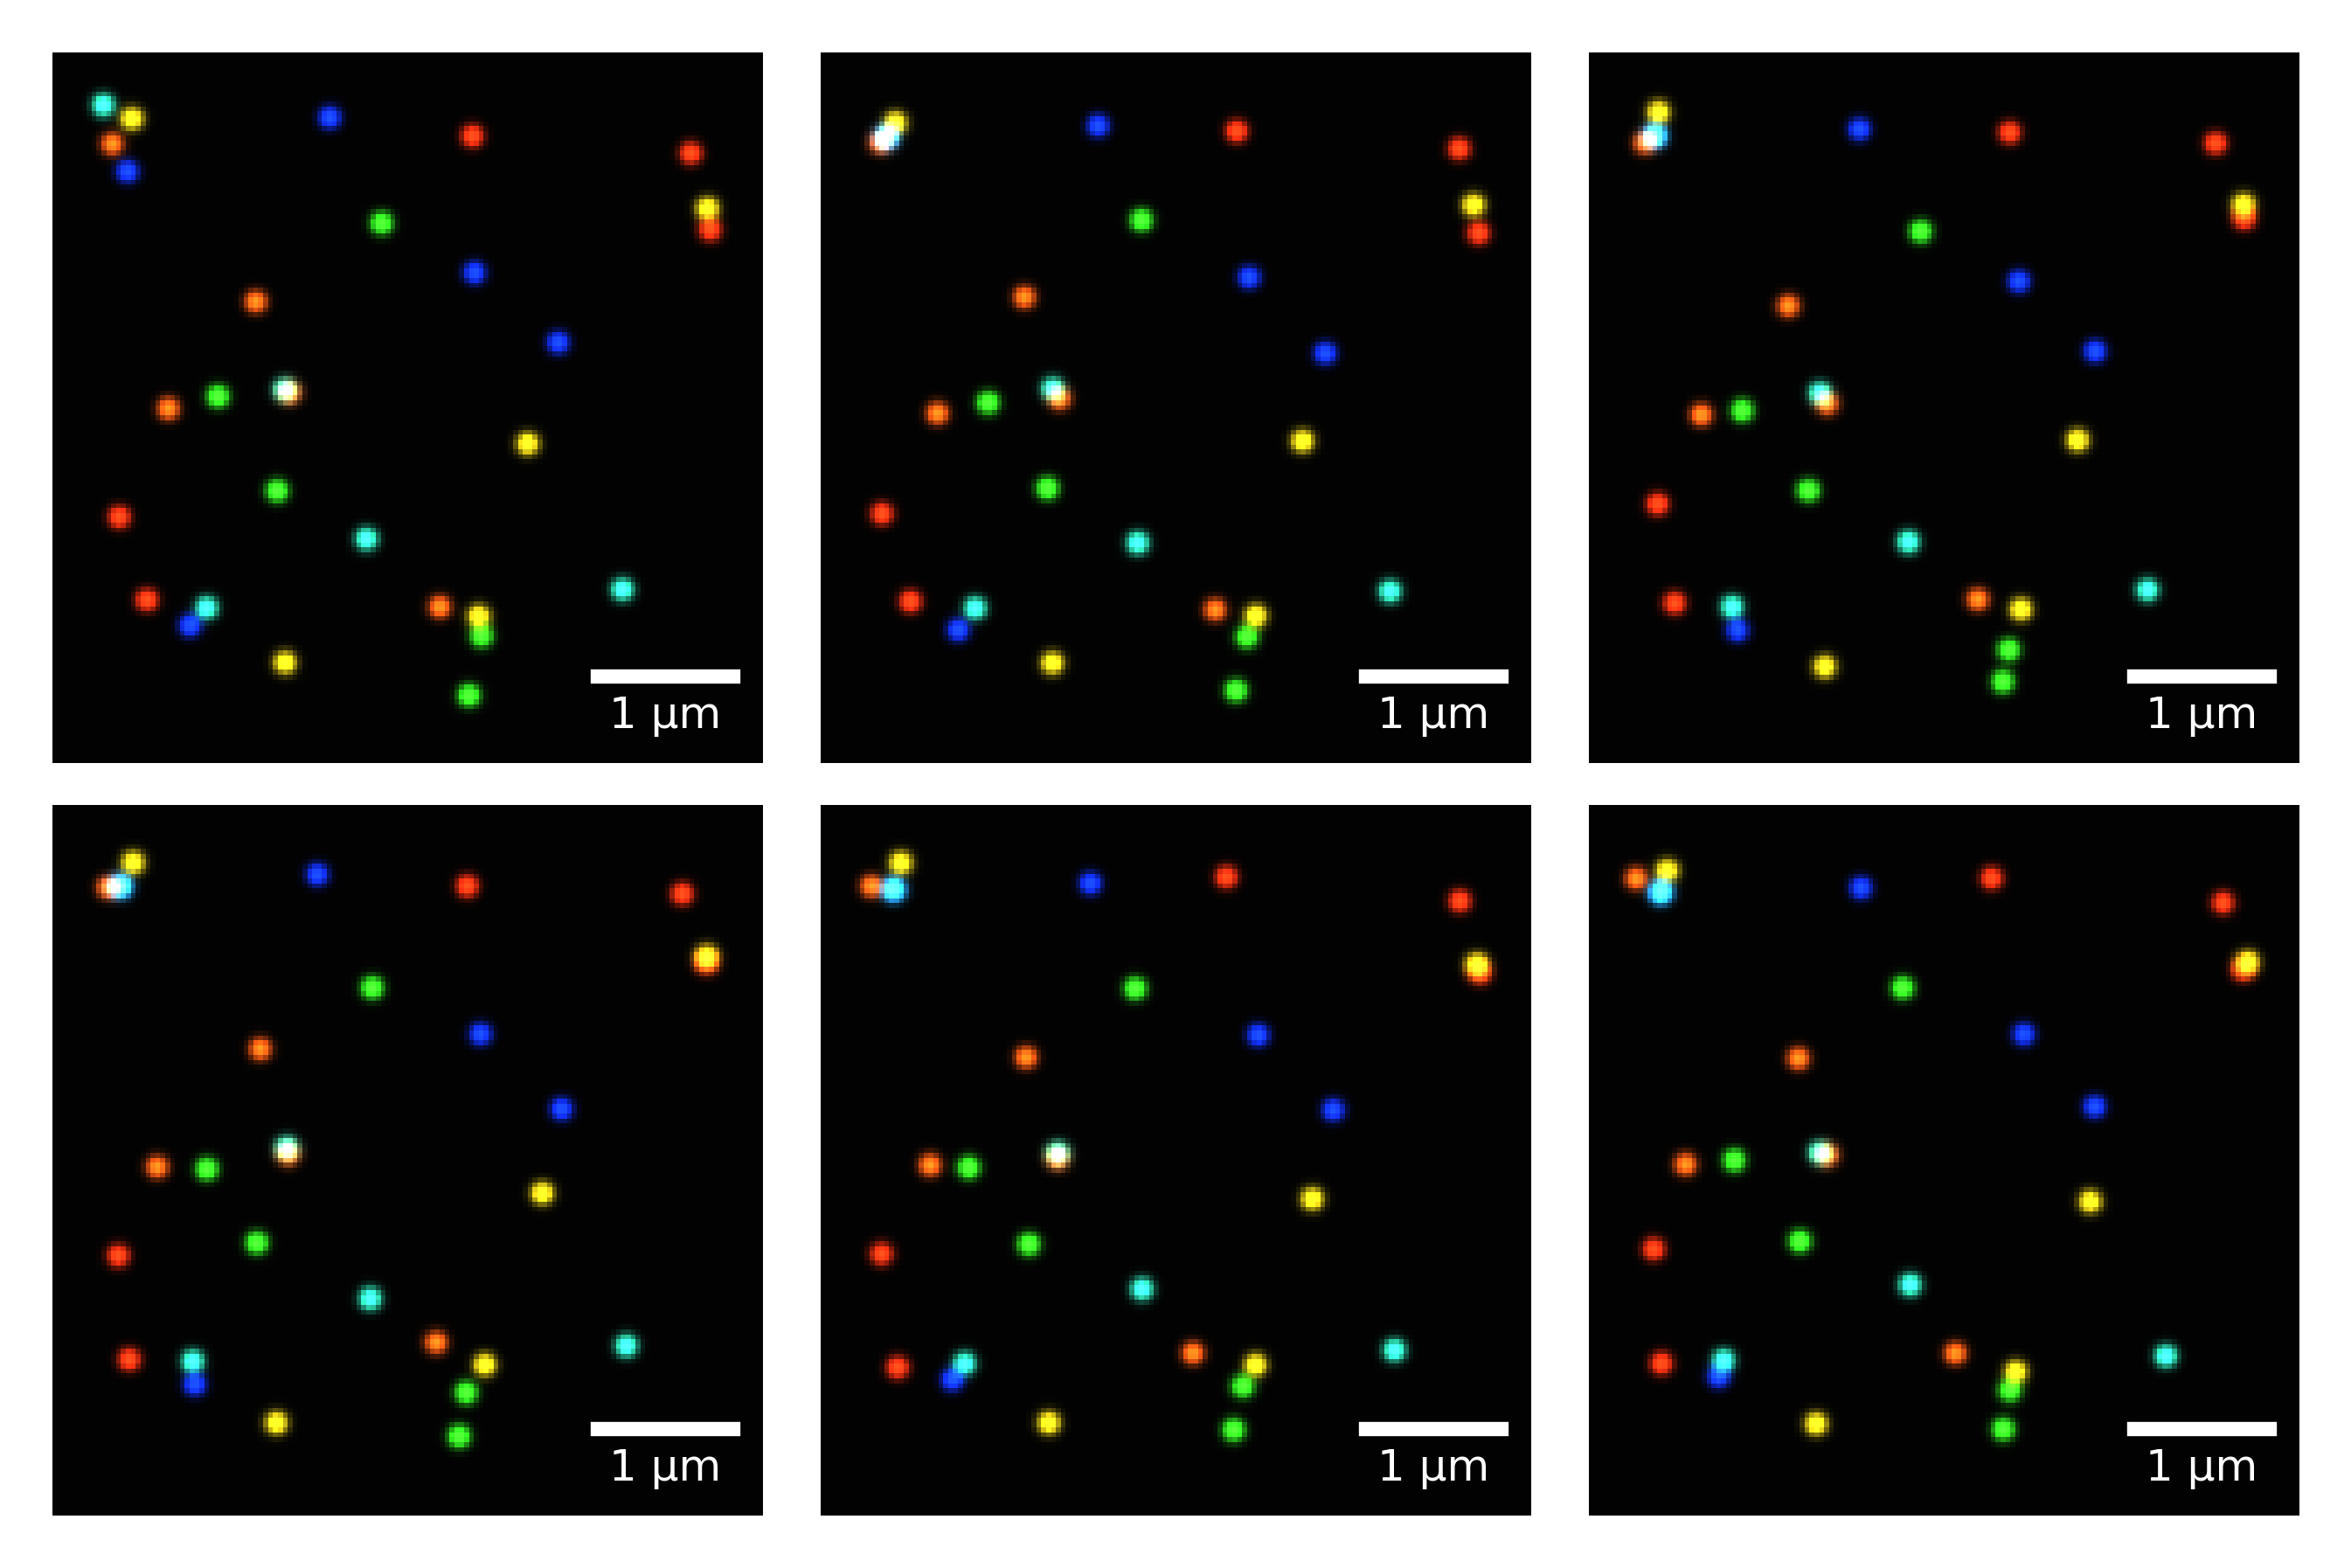


✅ Sample frames saved to: /tmp/stepwise_assembly_frames.svg
   Panel size: 1.5 × 1.5 inches each (4.5 × 3.0 inches total)
   Scalebar: 1.0 μm


In [24]:
# Plot sample frames using PlottingBase with scalebars
from PlottingBase import PublicationPlotter

# Timepoints to show (seconds)
timepoints = [0, 0.05, 0.1, 0.15, 0.2, 0.25]
frame_indices = [int(t * 1000 / dt) for t in timepoints]

# Create plotter
plotter = PublicationPlotter()

# Create 2×3 grid with 1.5×1.5 inch panels
# Total width: 3×1.5 = 4.5", Total height: 2×1.5 = 3.0"
fig, axes = plotter.two_column_plot(nrows=2, ncols=3, width=4.5, height=3.0)

for idx, (ax, t, f_idx) in enumerate(zip(axes.flat, timepoints, frame_indices)):
    if f_idx < rgb_video.shape[0]:
        # Get frame
        frame = rgb_video[f_idx]
        
        # Calculate scalebar size in nm
        # Want 1 μm scalebar
        scalebar_length_nm = 1000.0  # 1 μm in nm
        pixel_size_nm = 69.0 / 2  # 34.5 nm per pixel
        
        # For RGB images, need to handle differently (no cmap)
        if frame.ndim == 3:  # RGB
            # Plot RGB image directly
            ax.imshow(frame, origin='lower', interpolation='nearest')
            ax.axis('off')
            
            # Add title
            
            # Add scalebar manually
            plotter.add_scalebar(
                ax=ax,
                pixelsize=pixel_size_nm,
                length_nm=scalebar_length_nm,
                location='lower right',
                color='white',
                label='1 μm'
            )
        else:
            # Grayscale - use image_plot
            plotter.image_plot(
                ax=ax,
                image=frame,
                title=f't = {t:.2f} s',
                cmap='gray',
                scalebar=True,
                pixelsize=pixel_size_nm,
                scalebarsize=scalebar_length_nm,
                scalebarlabel='1 μm',
                scalebar_color='white',
                show_axes=False
            )
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', 
               transform=ax.transAxes, fontsize=8)
        ax.set_title(f't = {t:.1f} s', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig('stepwise_assembly_frames.svg', dpi=600, bbox_inches='tight')
plt.show()

print(f"\n✅ Sample frames saved to: /tmp/stepwise_assembly_frames.svg")
print(f"   Panel size: 1.5 × 1.5 inches each (4.5 × 3.0 inches total)")
print(f"   Scalebar: 1.0 μm")

Plotting tracks for each molecule...


/tmp/ipykernel_69431/2087221733.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


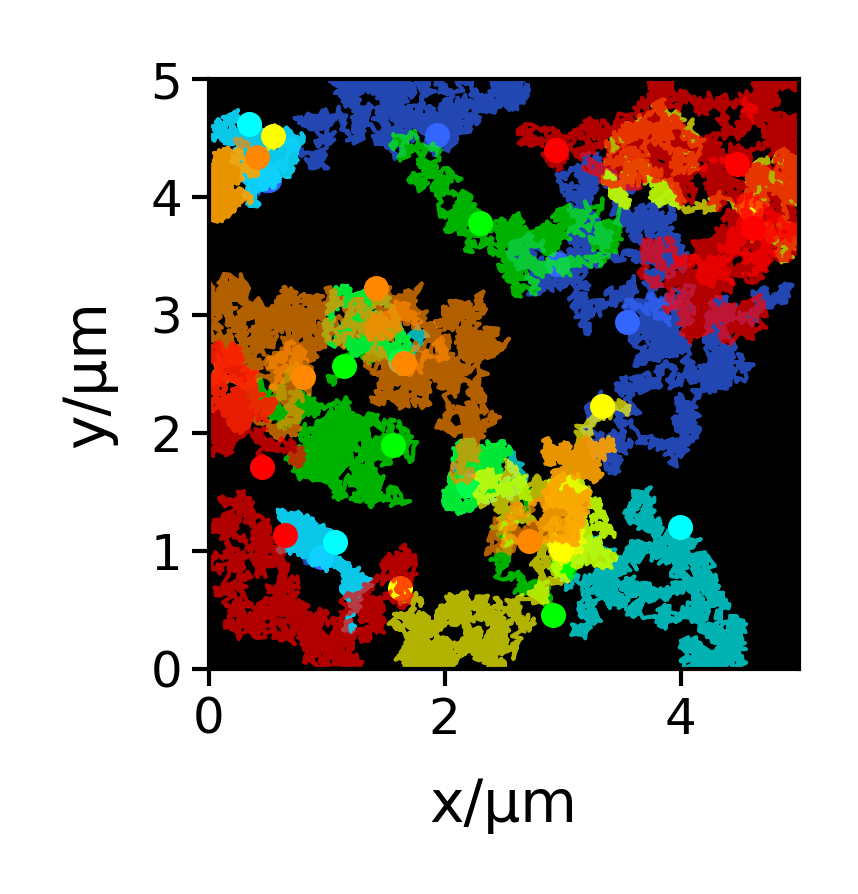


✅ Track plot saved to: /tmp/stepwise_assembly_tracks.svg
   Plotted 30 molecule trajectories
   Duration: 60.0 s (3000 frames)


In [19]:
# Plot molecule tracks using PlottingBase
from PlottingBase import PublicationPlotter

# Create figure with black background
plotter = PublicationPlotter()
fig, ax = plotter.one_column_plot(width=1.5, height=1.5)

# Set black background
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Define color mapping for each molecule type
color_map = {
    'Blue': '#3366FF',    # Bright blue
    'Cyan': '#00FFFF',    # Bright cyan
    'Green': '#00FF00',   # Bright green
    'Yellow': '#FFFF00',  # Bright yellow
    'Orange': '#FF8800',  # Bright orange
    'Red': '#FF0000'      # Bright red
}

print("Plotting tracks for each molecule...")

# Plot tracks for each molecule
for mol in simulator.molecules:
    # Get trajectory
    positions = np.array(mol.trajectory)
    x_coords = positions[:, 0]/1000  # um
    y_coords = positions[:, 1]/1000  # um
    
    # Get color
    color = color_map.get(mol.color, '#FFFFFF')
    
    # Plot track
    ax.plot(x_coords, y_coords, color=color, linewidth=0.5, alpha=0.7)
    
    # Mark start position with a dot
    ax.plot(x_coords[0], y_coords[0], 'o', color=color, markersize=2, alpha=1)

# Configure axes
ax.set_xlabel('x/µm', color='black', fontsize=7)
ax.set_ylabel('y/µm', color='black', fontsize=7)

# Set axis limits to simulation area
ax.set_xlim(0, area[0]/1000)
ax.set_ylim(0, area[1]/1000)

# Make tick labels white
ax.tick_params(colors='black', labelsize=6)
for spine in ax.spines.values():
    spine.set_color('black')

# Add legend
from matplotlib.patches import Patch
for text in legend.get_texts():
    text.set_color('black')

# Set aspect ratio equal
ax.set_aspect('equal', 'box')

# Save figure
plt.tight_layout()
plt.savefig('stepwise_assembly_tracks.svg', 
            dpi=600, 
            bbox_inches='tight',
            edgecolor='none')
plt.show()

print(f"\n✅ Track plot saved to: /tmp/stepwise_assembly_tracks.svg")
print(f"   Plotted {len(simulator.molecules)} molecule trajectories")
print(f"   Duration: {duration} s ({n_frames} frames)")

In [ ]:
simulator.molecules

## 8. Analyze Binding State Over Time

Track the number of bound molecules throughout the simulation.

In [ ]:
# Analyze binding state over time
# Count bound molecules at each frame
binding_events = simulator.binding_kinetics.binding_events
unbinding_events = simulator.binding_kinetics.unbinding_events

bound_count = np.zeros(n_frames)

for frame_idx in range(n_frames):
    time_ms = frame_idx * dt
    
    # Track bound pairs as sets to avoid double counting
    bound_pairs = set()
    
    # Process all binding events up to this time
    for bind_event in binding_events:
        if bind_event['time'] <= time_ms:
            mol1_id = bind_event['mol1_id']
            mol2_id = bind_event['mol2_id']
            pair = tuple(sorted([mol1_id, mol2_id]))
            bind_time = bind_event['time']
            
            # Check if this pair has unbound by this time
            is_still_bound = True
            for unbind_event in unbinding_events:
                unbind_mol1 = unbind_event['mol1_id']
                unbind_mol2 = unbind_event['mol2_id']
                unbind_pair = tuple(sorted([unbind_mol1, unbind_mol2]))
                
                if (unbind_pair == pair and 
                    unbind_event['time'] > bind_time and 
                    unbind_event['time'] <= time_ms):
                    # This pair unbound after binding, before current time
                    is_still_bound = False
                    break
            
            if is_still_bound:
                bound_pairs.add(pair)
    
    bound_count[frame_idx] = len(bound_pairs)

# Plot binding progression
fig, ax = plt.subplots(figsize=(12, 6))

time_s = np.arange(n_frames) * dt / 1000
ax.plot(time_s, bound_count, linewidth=2, color='darkblue')
ax.fill_between(time_s, 0, bound_count, alpha=0.3, color='lightblue')

ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Number of Bound Pairs', fontsize=14)
ax.set_title('Assembly Progression Over Time', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, time_s[-1])
ax.set_ylim(0, bound_count.max() * 1.1 if bound_count.max() > 0 else 1)

plt.tight_layout()
plt.savefig('/tmp/stepwise_assembly_kinetics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Kinetics plot saved to: /tmp/stepwise_assembly_kinetics.png")
print(f"\nAssembly statistics:")
print(f"  Maximum bound pairs: {int(bound_count.max())}")
print(f"  Average bound pairs: {bound_count.mean():.1f}")
print(f"  Final state: {int(bound_count[-1])} bound pairs")

## 9. Summary and Next Steps

**Outputs Generated:**
1. `/tmp/stepwise_assembly_rgb.tiff` - Ground truth RGB video (3000 frames)
2. `/tmp/stepwise_assembly_frames.png` - Sample frames showing assembly
3. `/tmp/stepwise_assembly_kinetics.png` - Binding progression over time

**What to look for in the RGB video:**
- Individual molecules appear as single colors (Blue, Cyan, Green, Yellow, Orange, Red)
- When molecules bind, their colors blend together
- Bound complexes diffuse more slowly (D_bound < D_free)
- Stepwise assembly creates multi-color complexes

**Next Steps:**
1. **Generate Bayer-filtered TIFF stack** for realistic camera simulation
2. **Extract localizations** from Bayer stack using pyBayerSMLM pipeline
3. **Perform spectral unmixing** to identify molecule types
4. **Track trajectories** to measure binding kinetics
5. **Compare to ground truth** to validate pipeline accuracy

In [ ]:
binding_events = simulator.binding_kinetics.binding_events
unbinding_events = simulator.binding_kinetics.unbinding_events

print("="*80)
print("SIMULATION COMPLETE!")
print("="*80)
print(f"\nGenerated files:")
print(f"  1. {output_path}")
print(f"     - Ground truth RGB video ({n_frames} frames)")
print(f"     - Shows assembly as color mixing")
print(f"\n  2. /tmp/stepwise_assembly_frames.png")
print(f"     - Sample frames at t = 0, 5, 10, 15, 20, 25 s")
print(f"\n  3. /tmp/stepwise_assembly_kinetics.png")
print(f"     - Binding progression over time")
print(f"\nSimulation parameters:")
print(f"  - 6 molecule types (Blue, Cyan, Green, Yellow, Orange, Red)")
print(f"  - {n_per_species} molecules per type ({len(simulator.molecules)} total)")
print(f"  - Stepwise assembly: A+B → AB+C → ABC+D → ABCD+E → ABCDE+F")
print(f"  - Duration: {duration} s ({n_frames} frames)")
print(f"  - Binding events: {len(binding_events)}")
print(f"  - Unbinding events: {len(unbinding_events)}")
print(f"  - Total events: {len(binding_events) + len(unbinding_events)}")
print(f"\nNext: Test with real pyBayerSMLM pipeline!")
print("="*80)